In [1]:
#!/usr/bin/env python

#set up imports
import sys
import argparse
import math
import random
import pickle


#import pygedm
import astropy.units as u
import astropy.coordinates as c

import inspect

import numpy as np 
import distributions_new as dists
import galacticops_new as go
import orbitalparams

import dist_gen as dg
from population import Population
from pulsar import Pulsar
from survey import Survey
import scipy.stats as stats

from progressbar import ProgressBar



if sys.version_info[0] < 3:
    import cPickle
else:
    import pickle as cPickle

class PopulateException(Exception):
    pass


import sys
import os


#from .pygemdm import ne21c
#from pygedm import ne21c
import pygedm








#set up generate function
def generate(ngen,
             surveyList=None,
             savepop=True,
             savefile='pulsarpop.pkl',
             pDistType='lnorm',
             radialDistType='lfl06',
             radialDistPars=7.5,
             electronModel='ne2001_F',
             pDistPars=[2.7, -0.34],
             siDistPars=[-1.6, 0.35],
             lumDistType='lnorm',
             lumDistPars=[-1.1, 0.9],
             zscaleType='exp',
             zscale=0.33,
             duty_percent=6.,
             scindex=-3.86,
             gpsArgs=[-1, -1],
             doubleSpec=[-1, -1],
             nostdout=False,
             pattern='gaussian',
             orbits=False,
             dgf=None,
             singlepulse=False,
             dither=False,
             accelsearch=False,
             jerksearch=False,
             sig_factor=10.0,
             bns = False,
             orbparams = {'m': [1, 5], 'm1': [1.0, 2.4], 'm2': [0.2, 1e9], 'om': [0, 360.], 'inc': [0, 90], 'ec': [0., 1.], 'pod': [1e-3, 1e3]},
             brDistType='log_unif'):
    
    #set up population object
    pop = Population()
    
    # check for d_g 
    if 'd_g' in (pDistType,lumDistType,zscaleType,radialDistType,brDistType) and dgf is None:
        print("Provide the distribution generation file")
        sys.exit()
    elif dgf != None:
        try:
            f = open(dgf, 'rb')
        except IOError:
            print("Could not open file {0}.".format(dgf))
            sys.exit()
        dgf_pop_load = cPickle.load(f)
        f.close()
        

        
    
    #draw periods
    pop.pDistType = pDistType
    pop.pmean= pDistPars[0]
    pop.psigma = abs(pDistPars[1])

    
    
    periods = get_periods(pop, ngen)

    #get spindex
    pop.simean, pop.sisigma = siDistPars
    spindex = np.random.normal(pop.simean,pop.sisigma,size=ngen)

   #frac and gps
    pop.gpsFrac, pop.gpsA = gpsArgs
    pop.brokenFrac, pop.brokenSI = doubleSpec

    gpsFlag = (np.random.random(ngen) < pop.gpsFrac).astype(int)

    brokenFlag = (np.random.random(ngen) < pop.brokenFrac).astype(int)
    
    
    #draw lumunmosity 
    pop.lumDistType = lumDistType
    
    #check the lum dist type and set up parameters
        
    if pop.lumDistType == 'lnorm':
        pop.lummean, pop.lumsigma = \
                lumDistPars[0], lumDistPars[1]
    elif pop.lumDistType == 'log_unif':
        pop.lumlow, pop.lumhigh = \
                lumDistPars[0], lumDistPars[1]
    elif pop.lumDistType == 'log_st':
        try:
            pop.lumlow, pop.lumhigh, pop.lumslope = \
                    lumDistPars[0], lumDistPars[1], lumDistPars[2]
        except ValueError:
            raise PopulateException('Not enough lum distn parameters')
    elif pop.lumDistType == 'd_g':
        pass
    else:
        try:
            pop.lummin, pop.lummax, pop.lumpow = \
            	lumDistPars[0], lumDistPars[1], lumDistPars[2]
        except ValueError:
            raise PopulateException('Not enough lum distn parameters')
    
    lum_1400 = get_lum1400(pop,ngen)
    
    
    #get radial dist
    if radialDistType not in ['lfl06', 'yk04', 'isotropic',
                              'slab', 'disk','unif' ,'gauss','d_g', 'gamma']:
        print("Unsupported radial distribution: {0}".format(radialDistType))
        
    pop.radialDistType = radialDistType
    pop.rsigma = radialDistPars
    pop.zscaleType = zscaleType
    pop.zscale = zscale
    
    
    gl, gb, galCoords, r0 = get_galactic_positions(pop, ngen, go, dists, zscale)
    
    


    
    #Set whether system is BNS:
    pop.bns = bns
    pop.orbparams = orbparams
    m = m1 = m2 = om = inc = ec = pod = np.zeros(ngen)
    if pop.bns: 
        assert isinstance(orbparams, dict), "Orbital parameter distribution limits should be a dictionary of form {'name of orb_param': [min, max]}"
        
        #These represents the range in which NN was trained. 
        #DO NOT GO OUTSIDE THESE BOUNDS!!
        default_orbparams = {'m': [1, 5], 'm1': [1.0, 2.4], 'm2': [0.2, 1e9], 'om': [0, 360.], 'inc': [0, 90], 'ec': [0., 1.], 'pod': [1e-3, 1e3]}
        
        if len(pop.orbparams) == 0: 
            print("Warning: Supplied orbparams dict is empty; Setting ranges to default")
            pop.orbparams = default_orbparams
        else:
            temp_opd = dict(default_orbparams)
            temp_opd.update(orbparams)
            pop.orbparams = temp_opd
    
   
            m,m1,m2,om,inc,ec,pod= binary_par(pop,ngen)
            print('Binary')  
        
        #get the distance
    rsun = 8.5
    dtrue = np.sqrt(galCoords[:, 0]**2+ (galCoords[:, 1] - rsun)**2+ galCoords[:, 2]**2)
    
##############################################################################        
   #dither the distance
    if dither:
        # find flux
        flux = lum_1400/(np.array(dtrue)**2)
        # dithered distance
        dold = dtrue
        dtrue=np.array(dtrue)
        dtrue += random.gauss(0.0,0.2*dtrue)
        # new luminosity
        lum_1400 = flux*dtrue**2
        lum_inj_mu=lum_1400
        # new R and z
        x,y,z = go.lb_to_xyz(gl, gb,dtrue)
        galCoords = np.column_stack((x, y, z))
        r0=np.sqrt(x**2 + y**2) 
   #get the dm ##############################################################################################################################
     #get the DM
    pop.electronModel = electronModel
    dm=[]
    tau_sc=[]
    
        
    if pop.electronModel == 'ne2001':
        for i in range(ngen):
            DM, tau =pygedm.dist_to_dm( gl[i], gb[i],dtrue[i]*1000, method='ne2001') #takes distance in pc
            dm.append(DM)
            tau_sc.append(tau)
    elif pop.electronModel == 'ne2001_F':
        for i in range(ngen):
             DM = go.ne2001_dist_to_dm(dtrue[i], gl[i], gb[i])
             dm.append(DM)
             #tau_sc.append(tau_sc)
    elif pop.electronModel == 'lmt85':
        for i in range(ngen):
             dm1, tau = go.lmt85_dist_to_dm(dtrue[i], gl[i], gb[i])
             dm.append(dm1)
             tau_sc.append(tau)
    elif pop.electronModel == 'ymw16':
        for i in range(ngen):
                   #gl, gb, dist
             DM, tau = pygedm.dist_to_dm( gl[i], gb[i],dtrue[i]*1000, method='ymw16')
             dm.append(DM)
             tau_sc.append(tau)
    elif pop.electronModel =='ne2025':
        for i in range(ngen):
             gl, gb, dist
             DM, tau = pygedm.dist_to_dm( gl[i], gb[i],dtrue[i]*1000, method='ne2025')
             dm.append(DM)
             tau_sc.append(tau)
             
    #####################################################################################################################################

            #scattering
    scindex_arr = np.full(ngen, scindex)
    if pop.electronModel == 'ne2001_F':
        
        tau_sc = np.array([
            go.scatter_bhat(dm_i, scindex)
            for dm_i in dm])

    #duty cycle

    if duty_percent > 0:
        width = (duty_percent / 100.0) * periods**0.9

        width = np.log10(width)

        width_degree = dists.drawlnorm(width,0.3,ngen) * 360.0 / periods
    

    #get the burst rate 
    if brDistType not in ['log_unif']:
        print("Unsupported burst rate distribution: {0}".format(brDistType))

    if singlepulse:

        if brDistType == 'log_unif':
            br = (10.0**np.random.uniform(-0.5,3.0,ngen)) / 3600.0

   # elif brDistType == 'd_g':
        


    
   

    pop.population = []
    
    for i, P in enumerate(periods):
    
        p = Pulsar()
    
        p.period = P
    
        p.lum_1400 = lum_1400[i]
        p.lum_inj_mu = lum_1400[i]
    
        p.gl = gl[i]
        p.gb = gb[i]
        p.galCoords = galCoords[i]
        p.r0 = r0[i]
    
        p.m = m[i]
        p.m1 = m1[i]
        p.m2 = m2[i]
        p.om = om[i]
        p.inc = inc[i]
        p.ec = ec[i]
        p.pod = pod[i]
    
        p.dm = dm[i]
        p.dtrue = dtrue[i]
    
        p.spindex = spindex[i]
    
        p.gpsFlag = gpsFlag[i]
        p.gpsA = pop.gpsA
    
        p.brokenFlag = brokenFlag[i]
        p.brokenSI = pop.brokenSI
    
        p.scindex = scindex
        p.t_scatter = tau_sc[i]
    
        p.width_degree = width_degree[i]
    
        # required by dosurvey
        p.detected = False
        p.dead = False
        p.snr = None
    
        if dither:
            p.flux = flux[i]
        else:
            p.flux = None
    
        if singlepulse:
            p.br = br[i]
            p.lum_sig = sig_factor
            p.det_nos = 0
        else:
            p.br = None
            p.det_nos = None
    
        pop.population.append(p)
    
    pop.ndet = len(pop.population)

    
    # save
    if savepop == True: 
        with open(savefile, "wb") as f:
            pickle.dump(pop, f)

        print("Saved population as", savefile)
    
    return pop

    








def get_periods(pop, ngen):
    
    if pop.pDistType == 'lnorm':
        periods = dists.drawlnorm(pop.pmean, pop.psigma, ngen)

    elif pop.pDistType == 'unif':
        periods = np.random.uniform(
            pop.pmean - pop.psigma,
            pop.pmean + pop.psigma,
            size=ngen
        )

    elif pop.pDistType == 'norm':
        periods = np.random.normal(pop.pmean, pop.psigma, size=ngen)
    elif pop.pDistType == 'cc97':
        periods = np.array([_cc97() for _ in range(ngen)])

    elif pop.pDistType == 'gamma':
        #impliment good values for shape,scale
        shape, scale = pop.pmean, pop.psigma # mean and width
        periods = np.random.gamma(shape,scale,ngen)
        
    elif pop.pDistType == 'd_g':
        Pbin_num = dists.draw1d(
            dgf_pop_load['pHist'],
            size=ngen
        )
        Pmin = dgf_pop_load['pBins'][0]
        Pmax = dgf_pop_load['pBins'][-1]

        periods = (
            Pmin
            + (Pmax - Pmin)
            * (Pbin_num + np.random.random(size=ngen))
            / len(dgf_pop_load['pHist'])
        )

    elif pop.pDistType == 'lorimer12':
        periods = np.array(
            [_lorimer2012_msp_periods() for _ in range(ngen)]
        )


    else:
        raise ValueError(f"Unknown pDistType: {pop.pDistType}")

    return periods


def get_lum1400(pop,ngen):
    
    if pop.lumDistType == 'lnorm':
        lum_1400 = dists.drawlnorm(pop.lummean, pop.lumsigma, ngen)

    elif pop.lumDistType == 'pow':
        lum_1400 = dists.powerlaw(pop.lummin,pop.lummax,pop.lumpow,ngen)

   #this one doesn't seem to be in the dists
    elif pop.lumDistType == 'log_st':
        log_lum = pop.lumlow + dists.st_line(
            pop.lumslope,
            pop.lumhigh - pop.lumlow,
            size=ngen
        )
        lum_1400 = 10.0 ** log_lum

    elif pop.lumDistType == 'log_unif':
        lum_1400 = 10.0 ** dists.uniform(pop.lumlow,pop.lumhigh,ngen)

    elif pop.lumDistType == 'd_g':
        lHist = dgf_pop_load['lHist']
        lBins = dgf_pop_load['lBins']

        lbin_num = dists.draw1d(lHist, size=ngen)
        lmin, lmax = lBins[0], lBins[-1]

        logl = lmin + (lmax - lmin) * (
            lbin_num + np.random.random(size=ngen)
        ) / len(lHist)

        lum_1400 = 10.0 ** logl
        
    return lum_1400




def get_galactic_positions(pop, N, go, dists, zscale):

    gl = np.zeros(N)
    gb = np.zeros(N)
    galCoords = np.zeros((N, 3))
    r0 = np.zeros(N)

    # -------------------------
    # Radial distribution
    # -------------------------

    if pop.radialDistType == 'isotropic':

        u = np.random.random(N)
        gb = np.degrees(np.arcsin(u))
        signs = np.where(np.random.random(N) < 0.5, -1.0, 1.0)
        gb *= signs

        gl = np.random.random(N) * 360.0

        # pretend distance = 1 kpc
        x,y,z = go.lb_to_xyz(gl, gb, np.ones(N))
       
    
    elif pop.radialDistType == 'slab':

        galCoords = go.slabdist(N)
        gl, gb = go.xyz_to_lb(galCoords)

    elif pop.radialDistType == 'disk':

        galCoords = go.diskdist(N)
        gl, gb = go.xyz_to_lb(galCoords)

    else:

        # -------- r0 models --------
        if pop.radialDistType == 'lfl06':
            r0 = go.lfl06(N)

        elif pop.radialDistType == 'gamma':
            fit_alpha = 1050.312227
            fit_loc   = -8.12315263841
            fit_beta  = 0.00756010693478

            r0 = 8.5 * stats.gamma.rvs(
                fit_alpha,
                loc=fit_loc,
                scale=fit_beta,
                size=N
            ) + 8.5

        elif pop.radialDistType == 'd_g':
            Rbin_num = dists.draw1d(dgf_pop_load['RHist'], size=N)

            Rmin = dgf_pop_load['RBins'][0]
            Rmax = dgf_pop_load['RBins'][-1]

            r0 = Rmin + (Rmax - Rmin) * (
                (Rbin_num + np.random.random(N)) /
                len(dgf_pop_load['RHist'])
            )

        elif pop.radialDistType == 'yk04':
            r0 = go.ykr(N)

        elif pop.radialDistType == 'unif':
            r0 = np.random.uniform(0, 12.3, N)

        elif pop.radialDistType == 'gauss':
            r0 = np.random.normal(0., pop.rsigma, N)

        # -------- z distribution --------
        if pop.zscaleType == 'exp':
            zheight = go._double_sided_exp(zscale, size=N)

        elif pop.zscaleType == 'unif':
            zheight = np.random.uniform(
                -1.06489765758,
                 1.91849552866,
                 N
            )

        elif pop.zscaleType == 'd_g':
            zbin_num = dists.draw1d(dgf_pop_load['ZHist'], size=N)

            logzmin = dgf_pop_load['ZBins'][0]
            logzmax = dgf_pop_load['ZBins'][-1]

            logz = logzmin + (logzmax - logzmin) * (
                (zbin_num + np.random.random(N)) /
                len(dgf_pop_load['ZHist'])
            )

            zheight = logz

        else:
            zheight = np.random.normal(0., zscale, N)

        # -------- convert to xyz --------
        # assume cylindrical: (r0, phi, zheight)

        phi = np.random.uniform(0, 2*np.pi, N)

        x = r0 * np.cos(phi)
        y = r0 * np.sin(phi)
        z = zheight

        galCoords = np.column_stack((x, y, z))

        gl, gb = go.xyz_to_lb(galCoords)

    return gl, gb, galCoords, r0

def binary_par(pop,ngen):
            
        m = np.zeros(ngen)
        m1= np.zeros(ngen)
        om = np.zeros(ngen)
        inc = np.zeros(ngen)
        ec = np.zeros(ngen)
        pod = np.zeros(ngen)
      
        
        #Draw a value for each of the orbital parameters from a uniform distribution
        m = np.random.uniform(pop.orbparams['m'][0], pop.orbparams['m'][1], size = ngen).astype(int)
        m1 = np.random.uniform(pop.orbparams['m1'][0], pop.orbparams['m1'][1], size = ngen)
        m2 = np.random.uniform(pop.orbparams['m2'][0], pop.orbparams['m2'][1], size = ngen)
        om = np.random.uniform(pop.orbparams['om'][0], pop.orbparams['om'][1], size = ngen)
        inc = np.random.uniform(pop.orbparams['inc'][0], pop.orbparams['inc'][1], size = ngen)
        ec = np.random.uniform(pop.orbparams['ec'][0], pop.orbparams['ec'][1], size = ngen)
        pod = np.random.uniform(pop.orbparams['pod'][0], pop.orbparams['pod'][1], size = ngen)
        
        return m,m1,m2,om,inc,ec,pod
    
    



def _cc97():
    """A model for MSP period distribution."""
    p = 0.0

    # pick p from the distribution, but cut off at 1 and 30 ms
    while p < 1.0 or p > 30.0:
        p = 0.65 / (1 - random.random())

    return p


def _lorimer2012_msp_periods():
    """Picks a period at random from Dunc's
       distribution as mentioned in IAU
       (China 2012) proceedings
    """
    # min max and n in distribution
    logpmin = 0.
    logpmax = 1.5
    dist = [1., 3., 5., 16., 9., 5., 5., 3., 2.]

    # calculate which bin to take value of
    #
    bin_num = dists.draw1d(dist)

    # assume linear distn inside the bins
    logp = logpmin + (logpmax-logpmin)*(bin_num+random.random())/len(dist)

    return 10.**logp





In [12]:
import dosurvey
import time
# 1. Capture the start time
start_time = time.perf_counter()

# 2. Run the target function
pulsars = generate(10000,nostdout=True,electronModel='ne2001_F',savepop=False)

# 3. Capture the end time and calculate elapsed seconds
end_time = time.perf_counter()
elapsed = end_time - start_time

print(f"Execution time: {elapsed:.6f} seconds")

Execution time: 2.577212 seconds


In [3]:
pulsars = generate(2,pDistType='lnorm',lumDistType='lnorm',electronModel='ne2001_F',radialDistType='lfl06',bns = True,dither=False)

Binary
Saved population as pulsarpop.pkl


In [4]:
import pickle

with open("pulsarpop.pkl", "rb") as f:
    pop = pickle.load(f)

print("Loaded", len(pop.population), "pulsars")

surveys_list=['AODRIFT']
surveyPops = dosurvey.run(
    pop,
    surveys_list,
    accelsearch=True
)

Loaded 10000 pulsars
Running doSurvey on population...


Running survey AODRIFT
Total pulsars in model = 10000
Number detected by survey AODRIFT = 2
Of which are discoveries = 2
Number too faint = 560
Number smeared = 204
Number out = 9234




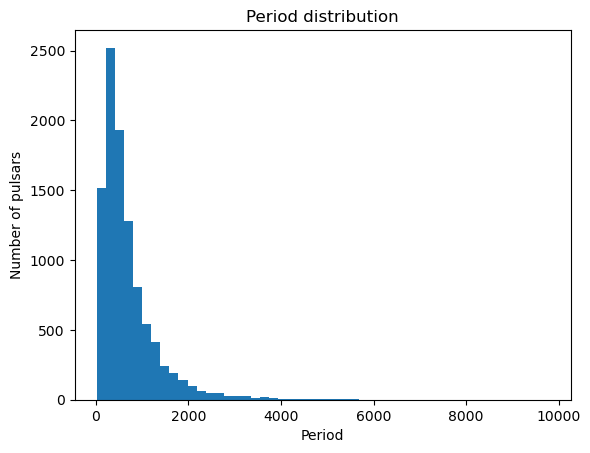

In [9]:
import matplotlib.pyplot as plt

periods = [p.period for p in pop.population]

plt.hist(periods, bins=50)
plt.xlabel("Period")
plt.ylabel("Number of pulsars")
plt.title("Period distribution")
plt.show()

In [7]:
# Save to CSV
import pandas as pd
data = []
for p in pulsars:
    data.append({
        'period': p.period,
        'lum_1400': p.lum_1400,
        'gl': p.gl,
        'gb': p.gb,
        'r0': p.r0,
        'dm': p.dm,
        'dtrue': p.dtrue,
        'm': p.m,
        'm1': p.m1,
        'm2': p.m2,
        'om': p.om,
        'inc': p.inc,
        'ec': p.ec,
        'pod': p.pod
    })

df = pd.DataFrame(data)

# Save to CSV
df.to_csv('pulsar_population.csv', index=False)

print("Saved pulsar_population.csv")

Saved pulsar_population.csv


In [24]:
import pandas as pd

# Assume pulsars is a list of data
df = pd.DataFrame(pulsars, columns=['period'])
df.to_csv('pulsar_periods.csv', index=False)


In [23]:
import csv


with open('pulsars.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Period','Lum','Lum_inj,mu']) # Write header

    for pulsar in pulsars:
        writer.writerow([pulsars.period , pulsars.lum_1400, pulsars.lum_inj_mu, pulsars.gl,pulsars.gb,pulsars.galCoords,pulsars.ro,pulsars.m,pulsars.m2,pulsars.om,pulsars.inc,pulsars.ec,pulsars.pod,pulsars.dm,pulsars.dtrue,pulsars.flux])


AttributeError: 'list' object has no attribute 'period'

In [ ]:
p = Pulsar()
        #add periods
        p.period = P
        # add luminosities
        p.lum_1400   = lum_1400[i]
        p.lum_inj_mu = lum_1400[i]
        #add galatic coordinates
        p.gl = gl[i]
        p.gb = gb[i]
        p.galCoords = galCoords[i]
        p.r0 = r0[i]
        # add in orbital parameters
        p.m = m[i]
        p.m1= m1[i]
        p.m2=m2[i]
        p.om = om[i]
        p.inc = inc[i]
        p.ec = ec[i]
        p.pod = pod[i]
        p.dm=dm[i]
        p.dtrue=dtrue[i]
        if dither:
            p.flux=flux[i]
        pulsars.append(p)

In [8]:
import matplotlib.pyplot as plt
print(len(pulsars))
print(pulsars[0].period)
print(pulsars[0].lum_1400)
print(pulsars[0].dm)
print(pulsars[0].dtrue)
ec = [pulsar.ec for pulsar in pulsars]

10000
965.3284937297165
0.010154162040674979
456.5528259277344
14.360560988906727


3.4974730820571333e-07


Text(0.5, 1.0, 'Pulsar DM ne2001')

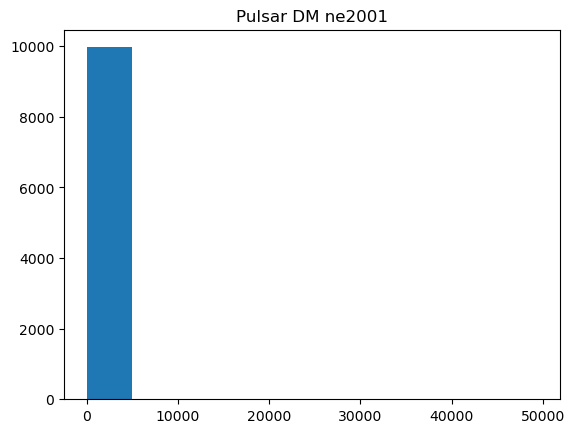

In [9]:
dm = [pulsar.t_scatter for pulsar in pulsars]
plt.hist(dm)
print(np.min(dm))
plt.title('Pulsar DM ne2001')

In [6]:
ec = [pulsar.t_scatter for pulsar in pulsars]
plt.hist(ec,bins=100)

NameError: name 'plt' is not defined

Text(0.5, 1.0, 'Populate_new')

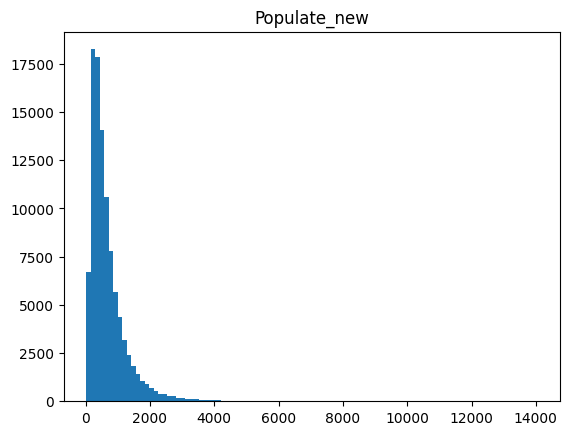

In [53]:

periods = [pulsar.period for pulsar in pulsars]
plt.hist(periods,bins=100)

plt.title('Populate_new')

0.7844922763920722 0 501.74403003165213


/tmp/ipykernel_388357/3870347872.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(x, pdf_fitted, 'r-', lw=2, label='Lognormal Fit',linestyle='--',alpha=.5)


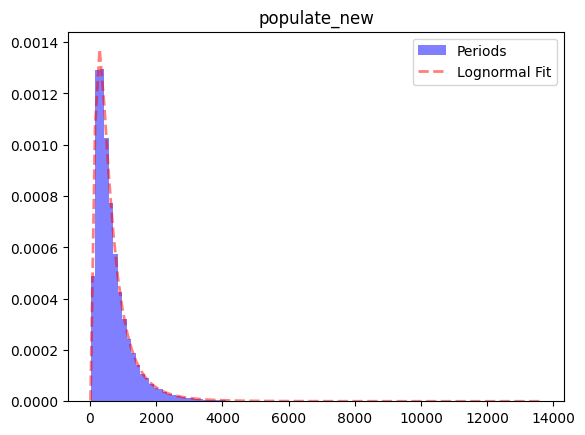

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# 1. Generate or import your data
data = periods

# 2. Fit the log-normal distribution to the data
shape_fit, loc_fit, scale_fit = lognorm.fit(data, floc=0) # floc=0 is often recommended

# 3. Create the histogram (must use density=True)
plt.hist(data, bins=100, density=True, alpha=0.5, color='blue', label='Periods')

# 4. Plot the fitted PDF curve
x = np.linspace(min(data), max(data), 100)
pdf_fitted = lognorm.pdf(x, shape_fit, loc=loc_fit, scale=scale_fit)
print(shape_fit,loc_fit,scale_fit)
plt.plot(x, pdf_fitted, 'r-', lw=2, label='Lognormal Fit',linestyle='--',alpha=.5)
plt.title('populate_new')
plt.legend()
plt.show()



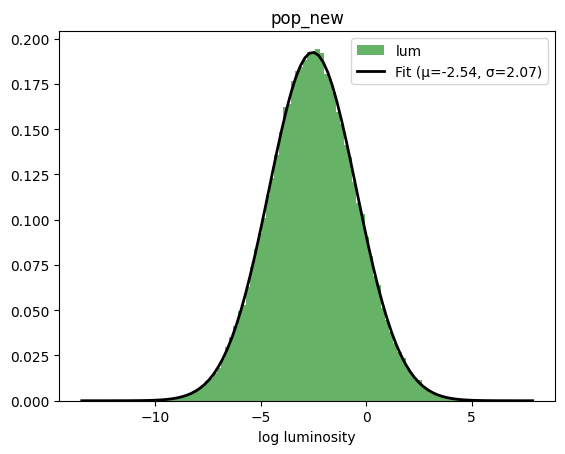

In [66]:
lum=np.log([pulsar.lum_1400 for pulsar in pulsars])


# 1. Generate or load your data
data = lum
# 2. Fit the distribution
mu, std = norm.fit(data)

# 3. Plot histogram (must use density=True to match PDF scale)
plt.hist(data, bins=100, density=True, alpha=0.6, color='g', label='lum')

# 4. Plot the PDF (Probability Density Function)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Fit (μ={mu:.2f}, σ={std:.2f})')
plt.title('pop_new')
plt.legend()
plt.xlabel('log luminosity')
plt.show()


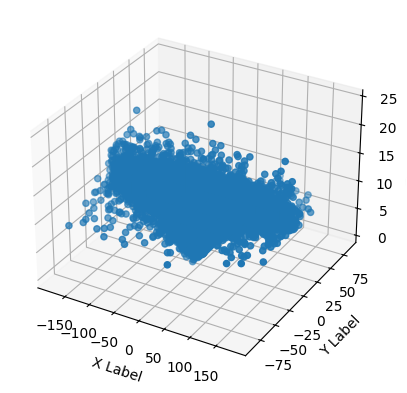

In [15]:
import matplotlib.pyplot as plt
import numpy as np


xs = [pulsar.gl for pulsar in pulsars]
ys = periods = [pulsar.gb for pulsar in pulsars]
zs = periods = [pulsar.r0 for pulsar in pulsars]
# Create a figure and add a 3D axes object
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Plot the 3D scatter plot
ax.scatter(xs, ys, zs)

# Label the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# Display the plot
plt.show()


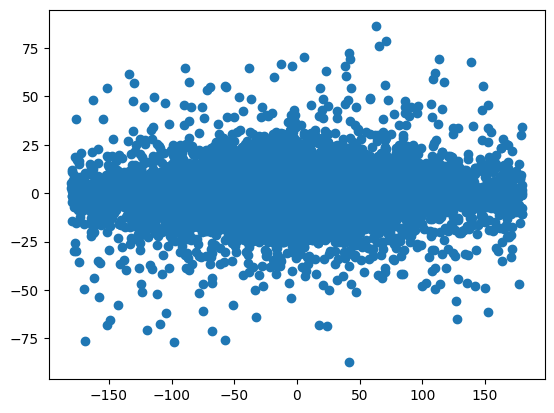

In [19]:
plt.scatter(xs,ys)